In [1]:
# @title Default title text
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ First 5 Rows of Data:
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 t

/tmp/ipython-input-3010681120.py:39: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


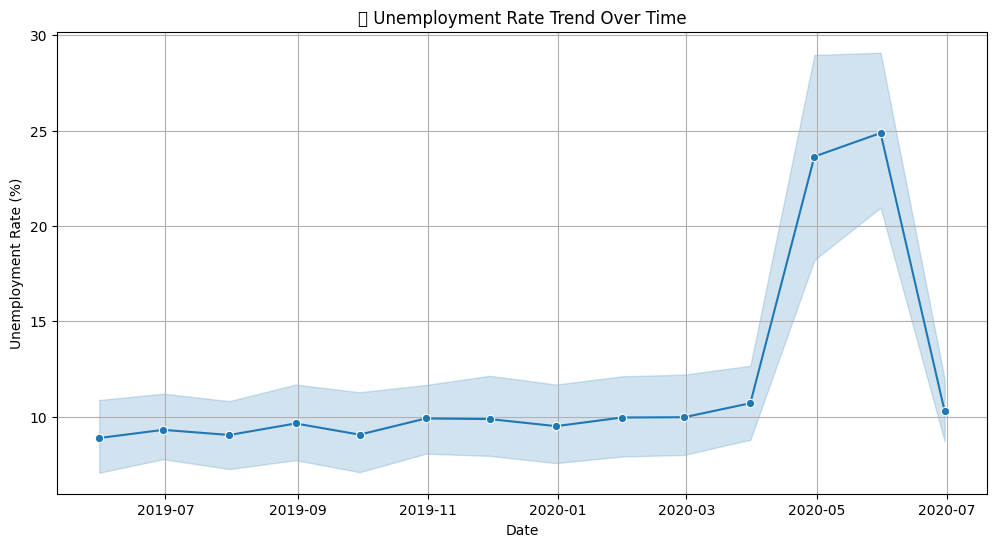

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


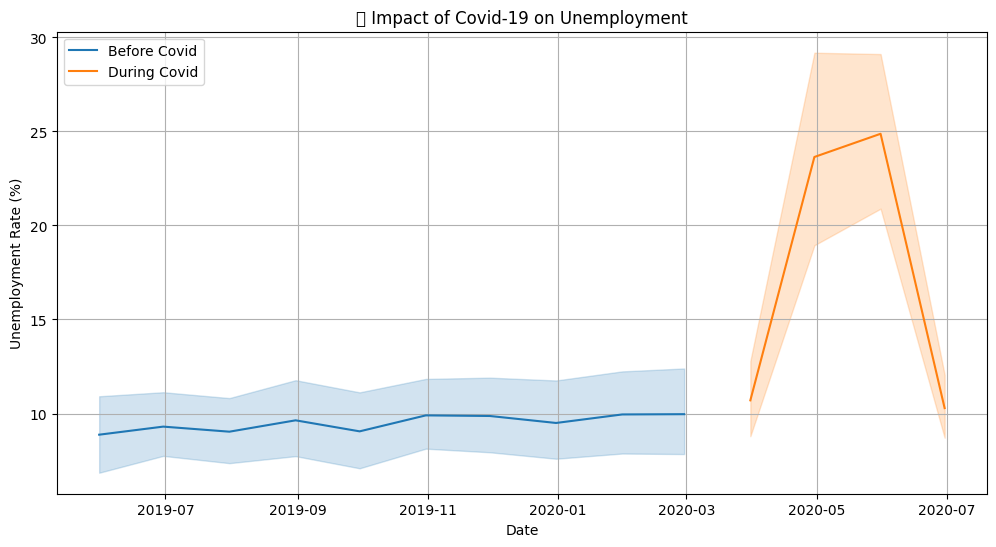

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


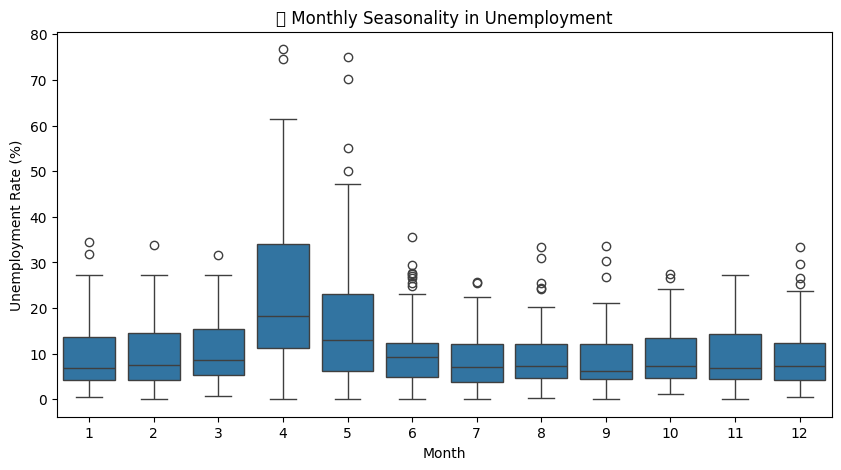

 Cleaned dataset saved to: /content/drive/MyDrive/unemployment_cleaned.csv


In [3]:
# @title Default title text
# ===============================
# 📊 Unemployment Analysis in Python
# ===============================



# STEP 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 3: Load Dataset from Google Drive
# 👉 Replace 'unemployment.csv' with your actual file name
file_path = '/content/drive/MyDrive/Task2Unemployment/Unemployment in India.csv'
df = pd.read_csv(file_path)

# Strip whitespace from column names
df.columns = df.columns.str.strip()


# STEP 4: Explore Data
print("✅ First 5 Rows of Data:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# STEP 5: Data Cleaning
# Fill missing values (if any) with forward fill method
# Using the suggested fix from the FutureWarning
df.ffill(inplace=True)


# Convert Date column (if exists) to datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')


# STEP 6: Basic Statistics
print("\nSummary Statistics:")
print(df.describe())

# STEP 7: Unemployment Trend Visualization
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df, marker='o')
plt.title("📉 Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# STEP 8: Covid-19 Impact Analysis
# Assuming Covid started around March 2020
covid_start = '2020-03-01'
before_covid = df[df['Date'] < covid_start]
during_covid = df[df['Date'] >= covid_start]

plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=before_covid, label="Before Covid")
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=during_covid, label="During Covid")
plt.title("📊 Impact of Covid-19 on Unemployment")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

# STEP 9: Seasonal / Monthly Trends
if 'Date' in df.columns:
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year

    plt.figure(figsize=(10,5))
    sns.boxplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
    plt.title("📆 Monthly Seasonality in Unemployment")
    plt.xlabel("Month")
    plt.ylabel("Unemployment Rate (%)")
    plt.show()

# STEP 10: Save Cleaned Dataset to Google Drive
clean_path = '/content/drive/MyDrive/unemployment_cleaned.csv'
df.to_csv(clean_path, index=False)
print(f" Cleaned dataset saved to: {clean_path}")